In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

In [3]:
# Tickers dos índices
ticker_idx_sp100 = '^OEX'
ticker_idx_ibov = '^BVSP'

In [4]:
# Período de análise
data_inicio = "2019-01-01"
data_fim = "2026-09-01"

In [5]:
#Definindo as ações do SP100 e IBOVESPA
SP100 = pd.read_csv("SP100_wikipedia_21set2026.csv", sep=",")
tickers_sp100 = SP100["Symbol"].tolist()
print(len(tickers_sp100), tickers_sp100) #Conferindo qnt e itens da lista

IBOVESPA = pd.read_csv("IBOVESPA_B3_24set2026.csv", sep=",")
tickers_ibov = IBOVESPA["Codigo"].tolist()
for i in range(len(tickers_ibov)): #loop para adicionar o sufixo ".SA" aos tickers do IBOVESPA
    tickers_ibov[i] = tickers_ibov[i] + ".SA"
print(len(tickers_ibov),tickers_ibov) #Conferindo qnt e itens da lista


101 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'ANET', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BMY', 'BNY', 'BRK-B', 'C', 'CAT', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DELL', 'DHR', 'DIS', 'DUK', 'EMR', 'FDX', 'GD', 'GE', 'GEV', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'MDLZ', 'MDT', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PFE', 'PG', 'PLTR', 'PM', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SNDK', 'SO', 'T', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UBER', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
76 ['ALOS3.SA', 'ABEV3.SA', 'ASAI3.SA', 'AURE3.SA', 'AXIA3.SA', 'AZZA3.SA', 'B3SA3.SA', 'BBSE3.SA', 'BBDC3.SA', 'BBDC4.SA', 'BRAP4.SA', 'BBAS3.SA', 'BRAV3.SA', 'BPAC11.SA', 'CXSE3.SA', 'CEAB3.SA', 'CMIG4.SA', 'COGN3.SA', 'CSMG3.SA', 'CPLE3.SA', 'CSAN3.SA', 'CPFE3.SA', 'C

In [20]:
#Extraindo os dados do SP100 e IBOVESPA do Yahoo Finance
print("Baixando S&P100...")
dados_sp100 = yf.download(tickers_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_sp100 = yf.download(ticker_idx_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Baixando IBOVESPA...")
dados_ibov = yf.download(tickers_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_ibov = yf.download(ticker_idx_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Tudo pronto!")

Baixando S&P100...
Baixando IBOVESPA...
Tudo pronto!


In [21]:
#Salvando localmente
dados_sp100.to_csv('sp100_precos.csv')
dados_ibov.to_csv('ibov_precos.csv')
indice_sp100.to_csv('sp100_indice.csv')
indice_ibov.to_csv('ibov_indice.csv')

In [22]:
print(f'\n✅ S&P100: {dados_sp100.shape[1]} ações × {dados_sp100.shape[0]} pregões')
print(f'✅ IBOV: {dados_ibov.shape[1]} ações × {dados_ibov.shape[0]} pregões')
print(f'\nPeríodo S&P100: {dados_sp100.index[0].date()} → {dados_sp100.index[-1].date()}')
print(f'Período IBOV: {dados_ibov.index[0].date()} → {dados_ibov.index[-1].date()}')
print('\nPrimeiras linhas S&P100:')
print(dados_sp100.head(3))



✅ S&P100: 101 ações × 1926 pregões
✅ IBOV: 76 ações × 1908 pregões

Período S&P100: 2019-01-02 → 2026-08-31
Período IBOV: 2019-01-02 → 2026-08-31

Primeiras linhas S&P100:
Ticker           AAPL       ABBV        ABT         ACN        ADBE  \
Date                                                                  
2019-01-02  37.436913  64.331535  60.370651  124.619781  224.570007   
2019-01-03  33.707928  62.211906  57.521477  120.365074  215.699997   
2019-01-04  35.146889  64.216171  59.163223  125.045288  226.190002   

Ticker           AMAT        AMD        AMGN         AMT       AMZN  ...  \
Date                                                                 ...   
2019-01-02  30.955572  18.830000  151.723373  127.991486  76.956497  ...   
2019-01-03  29.161863  17.049999  149.414703  128.759033  75.014000  ...   
2019-01-04  31.158991  19.000000  154.522217  129.273514  78.769501  ...   

Ticker      UBER         UNH         UNP        UPS        USB           V  \
Date        

In [23]:
# 1. Retorno logarítmico diário
ret_sp100 = np.log(dados_sp100 / dados_sp100.shift(1)).dropna(how='all')
ret_ibov = np.log(dados_ibov / dados_ibov.shift(1)).dropna(how='all')

ret_idx_sp = np.log(indice_sp100 / indice_sp100.shift(1)).dropna()
ret_idx_ib = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

# 2. Garantir extração de valores escalares para impressão (funciona para Series ou DataFrames)
val_media_sp = ret_idx_sp.values.mean() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.mean()
val_media_ib = ret_idx_ib.values.mean() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.mean()

val_std_sp = ret_idx_sp.values.std() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.std()
val_std_ib = ret_idx_ib.values.std() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.std()

# Formato das matrizes
print('Formato dos retornos S&P100:', ret_sp100.shape)
print('Formato dos retornos IBOV:  ', ret_ibov.shape)

# Exibição das estatísticas do benchmark
print(f'\nRetorno médio diário do S&P100: {val_media_sp:.4%}')
print(f'Retorno médio diário do IBOV:   {val_media_ib:.4%}')

print(f'\nVolatilidade diária S&P100:     {val_std_sp:.4%}')
print(f'Volatilidade diária IBOV:       {val_std_ib:.4%}')

# 3. Salvar retornos tratados
ret_sp100.to_csv('sp100_retornos.csv')
ret_ibov.to_csv('ibov_retornos.csv')

Formato dos retornos S&P100: (1925, 101)
Formato dos retornos IBOV:   (1907, 76)

Retorno médio diário do S&P100: 0.0636%
Retorno médio diário do IBOV:   0.0350%

Volatilidade diária S&P100:     1.2576%
Volatilidade diária IBOV:       1.4698%


=== DADOS FALTANTES,S&P100 ===
Total de ações: 101
Ações sem nenhum dado faltante: 97
Ações com algum dado faltante: 4

Ações com até 5% de dados faltantes:
Ticker
UBER    4.62
dtype: float64

Ações com mais de 5% de dados faltantes:
Ticker
SNDK    79.85
GEV     68.38
PLTR    22.85
dtype: float64


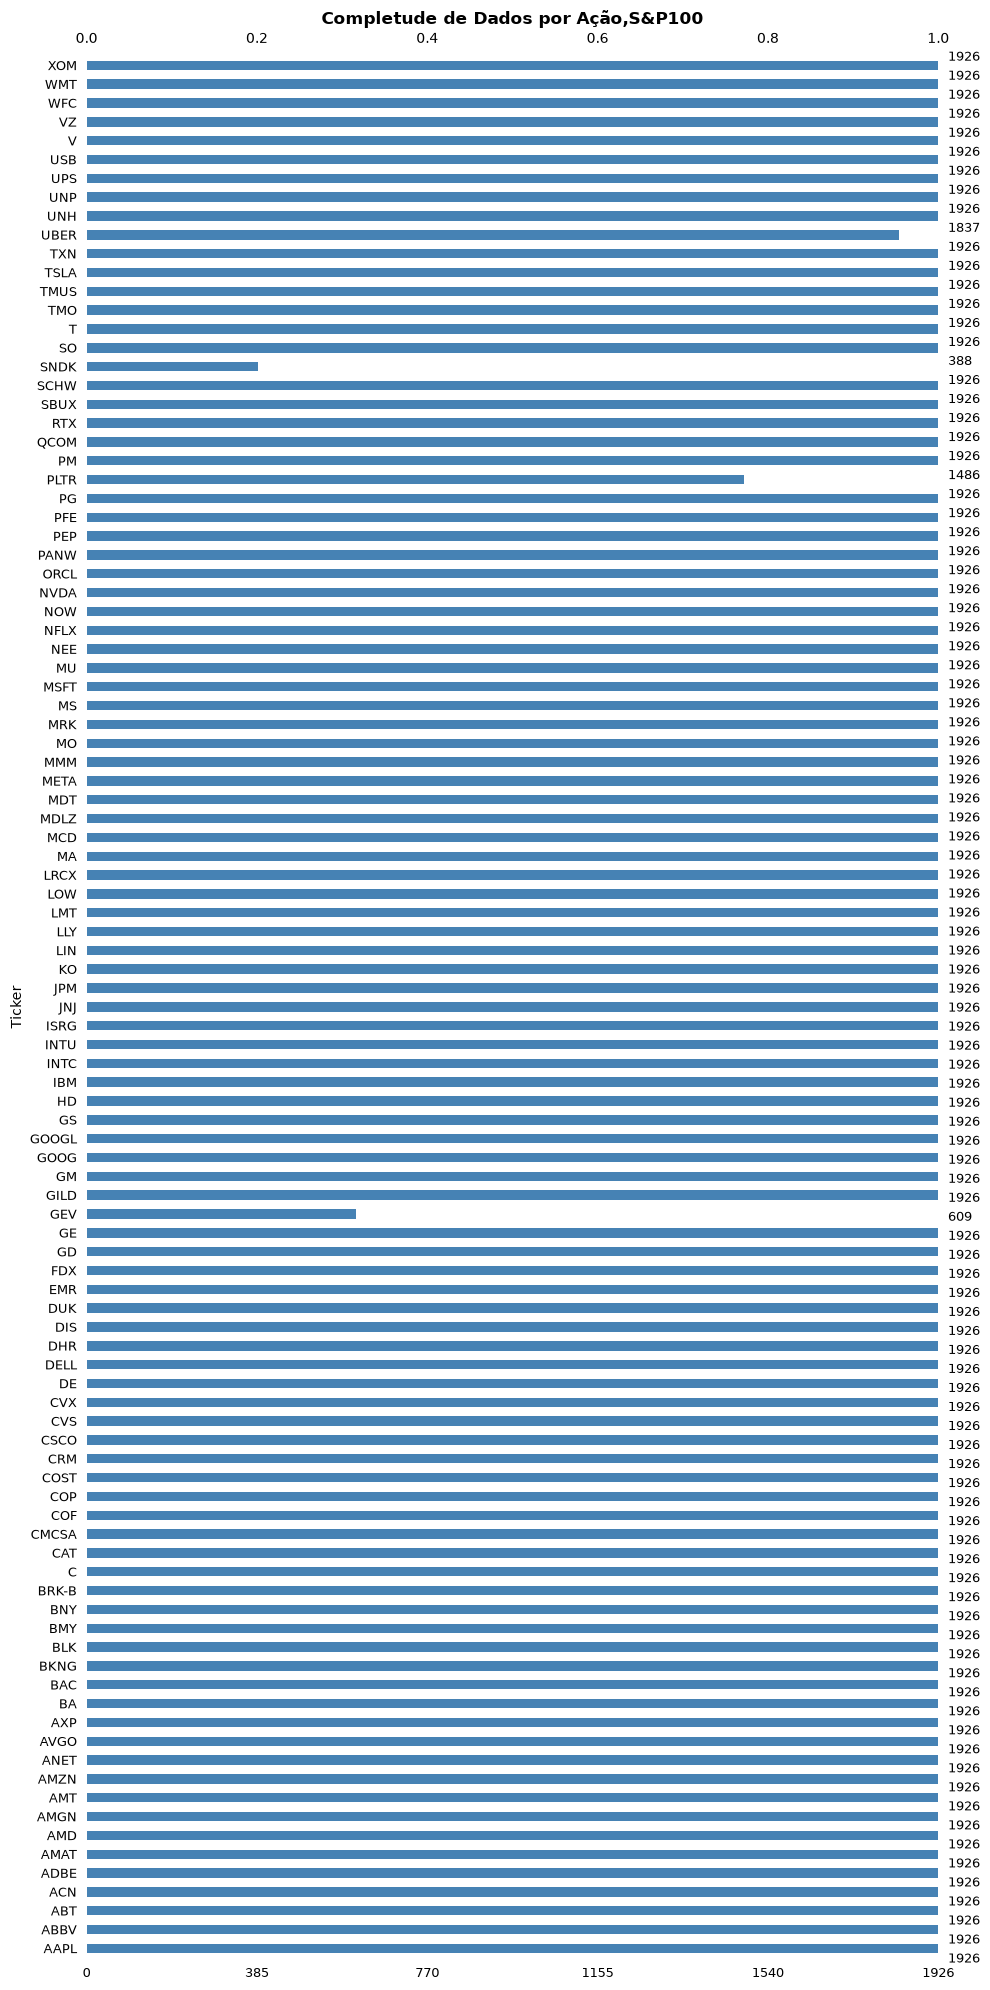

In [24]:
# Contagem e percentual de nulos por ação
nulos_sp = dados_sp100.isnull().sum()
pct_nulos = (nulos_sp / len(dados_sp100) * 100).round(2)
print('=== DADOS FALTANTES,S&P100 ===')
print(f'Total de ações: {dados_sp100.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes
fig, ax = plt.subplots(figsize=(10, 20))
msno.bar(dados_sp100, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação,S&P100', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_sp100.png', dpi=150)
plt.show()

=== DADOS FALTANTES,IBOVESPA ===
Total de ações: 76
Ações sem nenhum dado faltante: 63
Ações com algum dado faltante: 13

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
NATU3.SA     73.01
AURE3.SA     41.98
IGTI11.SA    37.47
SMFT3.SA     32.81
CXSE3.SA     30.14
ASAI3.SA     27.94
CMIN3.SA     27.67
VAMO3.SA     27.04
RDOR3.SA     25.47
BRAV3.SA     24.32
CURY3.SA     22.43
CEAB3.SA     11.11
VIVA3.SA     10.22
dtype: float64


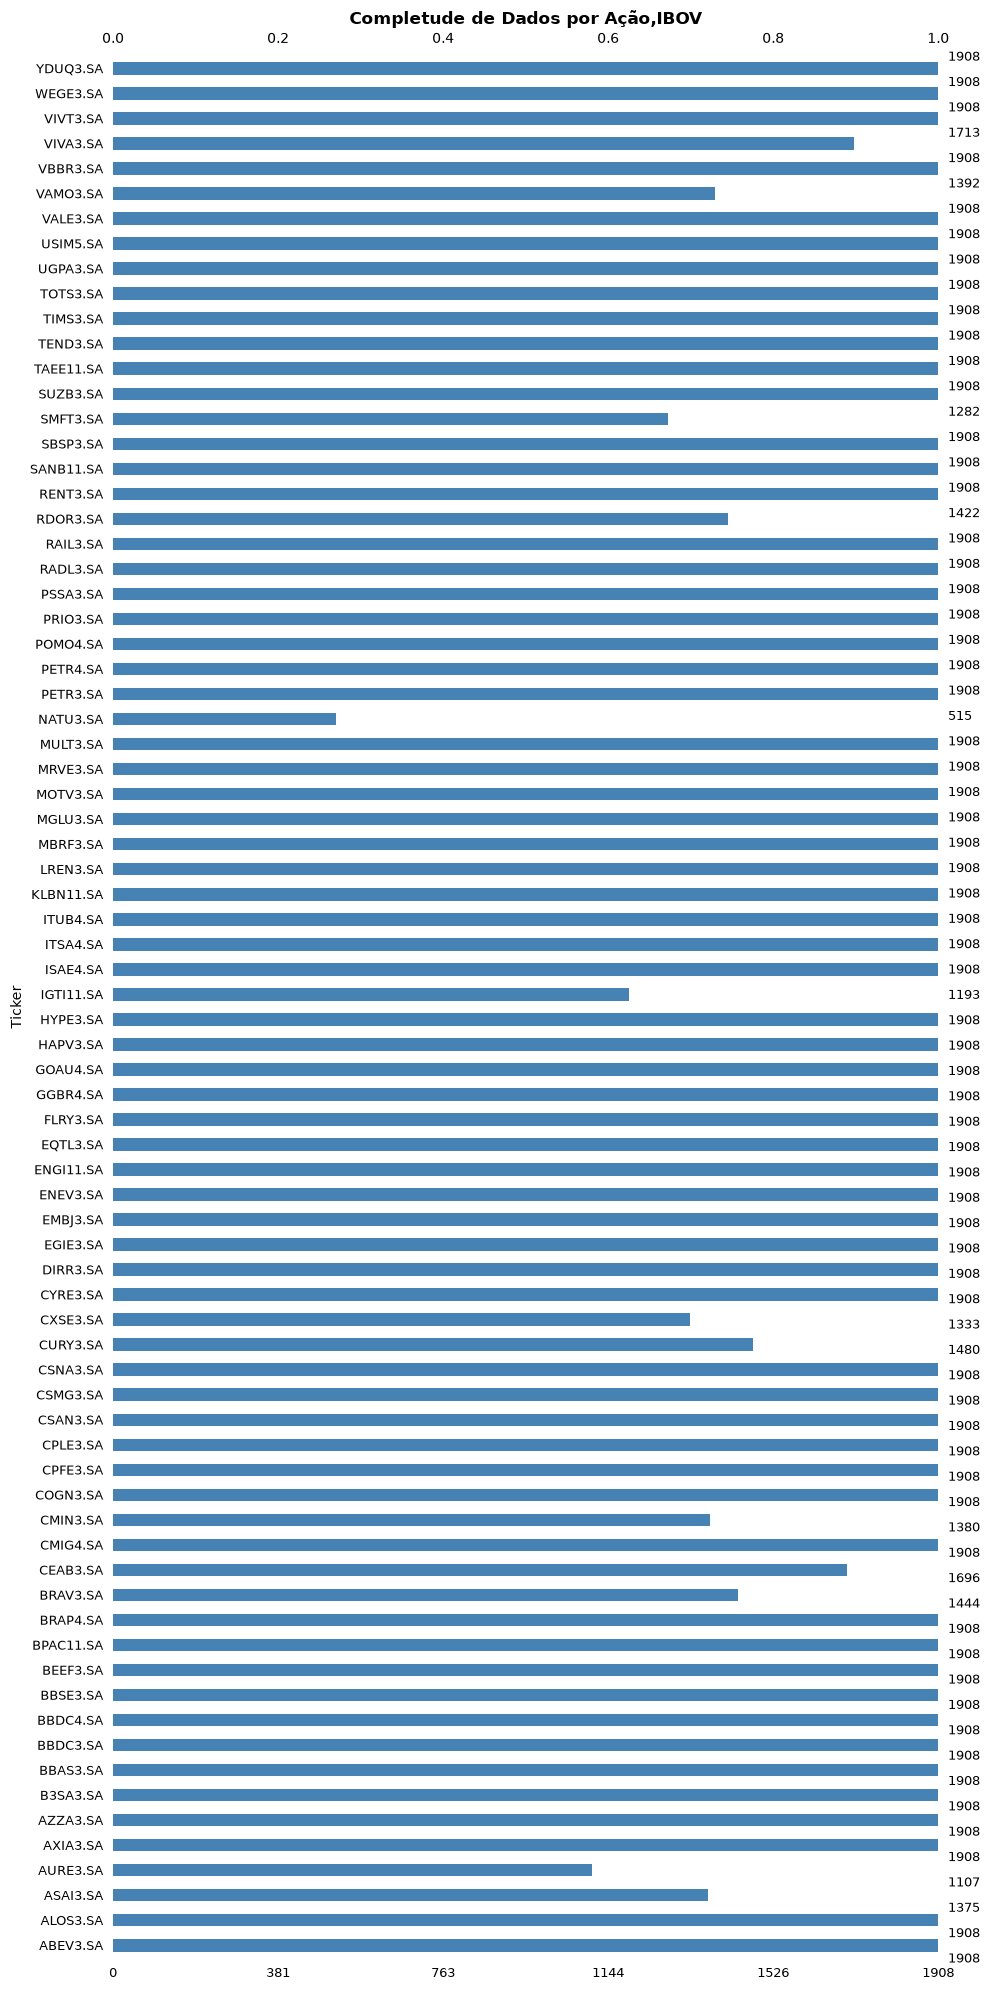

In [25]:
# Contagem e percentual de nulos por ação
nulos_sp = dados_ibov.isnull().sum()
pct_nulos = (nulos_sp / len(dados_ibov) * 100).round(2)
print('=== DADOS FALTANTES,IBOVESPA ===')
print(f'Total de ações: {dados_ibov.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes
fig, ax = plt.subplots(figsize=(10, 20))
msno.bar(dados_ibov, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação,IBOV', fontweight='bold')
plt.tight_layout()
plt.savefig('missing_ibov.png', dpi=150)
plt.show()

In [26]:
# 1. Definir o limite máximo tolerado de NaNs (ex: 5%)
limite_remocao = 5.0  

# 2. Calcular a porcentagem de nulos de CADA AÇÃO (por coluna)
pct_nulos_ibov = dados_ibov.isna().mean() * 100
pct_nulos_sp100 = dados_sp100.isna().mean() * 100

# 3. Filtrar as ações que estão DENTRO do limite e extrair os nomes
acoes_validas_ibov = pct_nulos_ibov[pct_nulos_ibov <= limite_remocao].index
acoes_validas_sp100 = pct_nulos_sp100[pct_nulos_sp100 <= limite_remocao].index

# 4. Criar o novo DataFrame filtrado contendo apenas as ações válidas
dados_ibov_clean = dados_ibov[acoes_validas_ibov]
dados_sp100_clean = dados_sp100[acoes_validas_sp100]



IBOVESPA
Total de ações originais: 76
Total de ações mantidas:  63

S&P100
Total de ações originais: 101
Total de ações mantidas:  98

Retornos finais,IBOV: (1907, 63)
Retornos finais,S&P100: (1836, 98)


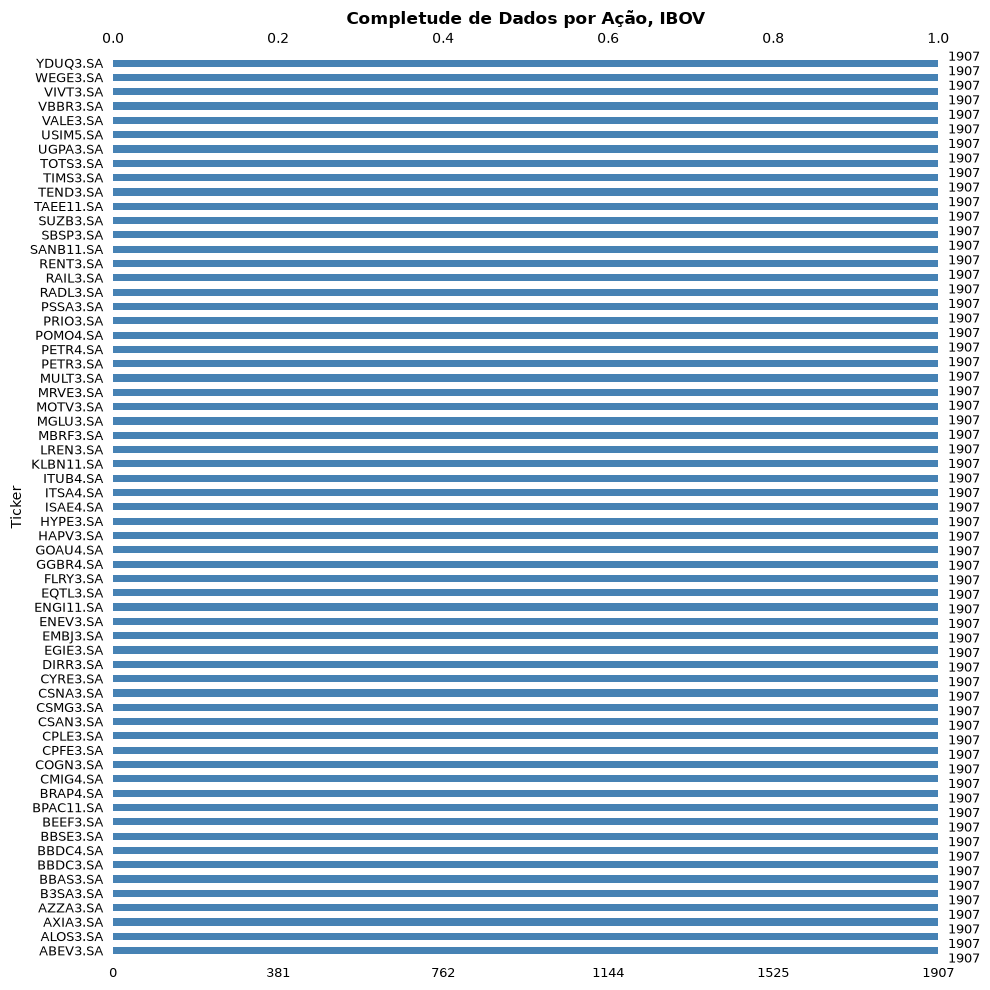

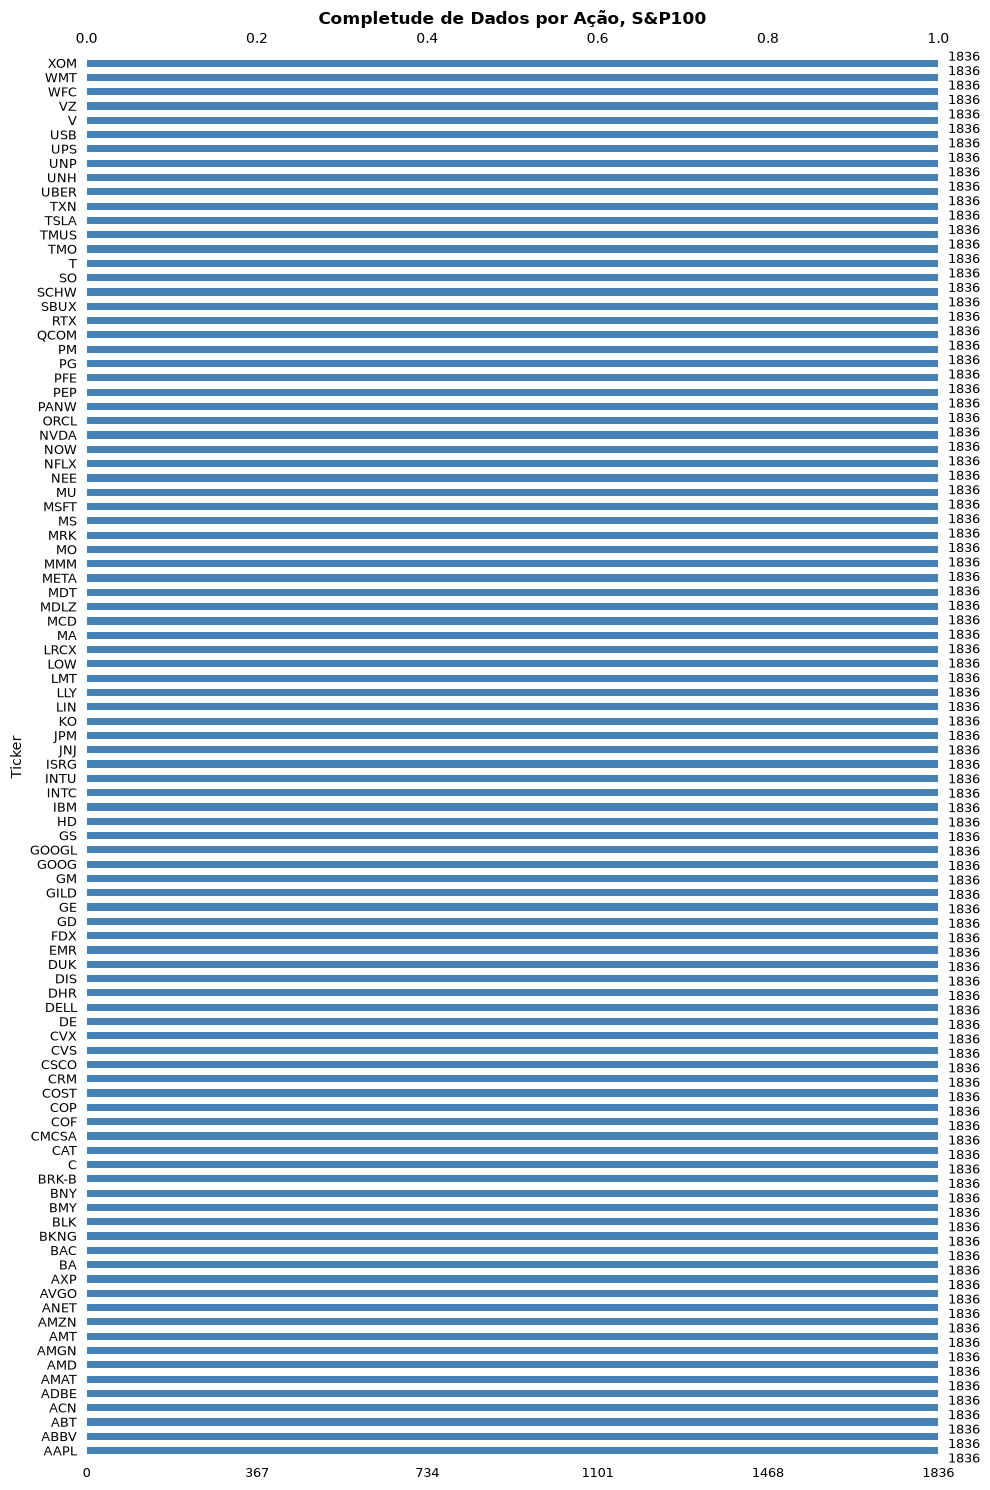

In [ ]:
# 1. Definir o limite máximo tolerado de NaNs (ex: 5%)
limite_remocao = 5.0  

# 2. Calcular a porcentagem de nulos de CADA AÇÃO (por coluna)
pct_nulos_sp100 = dados_sp100.isna().mean() * 100
pct_nulos_ibov = dados_ibov.isna().mean() * 100

# 3. Filtrar as ações que estão DENTRO do limite e extrair os nomes
acoes_validas_sp100 = pct_nulos_sp100[pct_nulos_sp100 <= limite_remocao].index
acoes_validas_ibov = pct_nulos_ibov[pct_nulos_ibov <= limite_remocao].index

# 4 Preencher dados faltantes (<5%) restantes com forward fill
dados_sp100_clean = dados_sp100_clean.ffill()
dados_ibov_clean = dados_ibov_clean.ffill()

# 5. Criar o novo DataFrame filtrado contendo apenas as ações válidas
dados_sp100_clean = dados_sp100[acoes_validas_sp100]
dados_ibov_clean = dados_ibov[acoes_validas_ibov]
print ("IBOVESPA")
print(f"Total de ações originais: {dados_ibov.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_ibov)}")

print ("\nS&P100")
print(f"Total de ações originais: {dados_sp100.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_sp100)}")

# 6. Verificar se ainda há nulos (linhas iniciais podem ter NaN)
dados_sp100_clean = dados_sp100_clean.dropna(how='all')
dados_ibov_clean = dados_ibov_clean.dropna(how='all')

# Recalcular retornos com dados limpos
ret_sp100_clean = np.log(dados_sp100_clean / dados_sp100_clean.shift(1)).dropna()
ret_ibov_clean = np.log(dados_ibov_clean / dados_ibov_clean.shift(1)).dropna()
print(f'\nRetornos finais,IBOV: {ret_ibov_clean.shape}')
print(f'Retornos finais,S&P100: {ret_sp100_clean.shape}')

# Visualização, mapa de calor de dados completos após limpeza
fig, ax = plt.subplots(figsize=(10, 10))
msno.bar(ret_ibov_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, IBOV', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 15))
msno.bar(ret_sp100_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, S&P100', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
#Identificação de Outliers nos Retornos
# Detectar retornos extremos por ação
limite_outlier = 0.15 # ±15% em um dia,ajuste conforme necessário
outliers_sp = (ret_sp100_clean.abs() > limite_outlier).sum()
print('Ações com retornos diários > 15% (S&P100):')
print(outliers_sp[outliers_sp > 0].sort_values(ascending=False).head(15))

outliers_ibov = (ret_ibov_clean.abs() > limite_outlier).sum()
print('\nAções com retornos diários > 15% (IBOV):')
print(outliers_ibov[outliers_ibov > 0].sort_values(ascending=False).head(15))

Ações com retornos diários > 15% (S&P100):
Ticker
TSLA    14
INTC     8
BA       8
AMD      7
DELL     7
LRCX     6
MU       6
META     6
NVDA     6
ANET     6
AVGO     5
BAC      4
CVX      4
MS       4
ISRG     4
dtype: int64

Ações com retornos diários > 15% (IBOV):
Ticker
PRIO3.SA     13
TEND3.SA     12
HAPV3.SA     11
MGLU3.SA     11
BPAC11.SA     8
YDUQ3.SA      8
COGN3.SA      7
MBRF3.SA      7
CSNA3.SA      7
AXIA3.SA      7
USIM5.SA      6
EMBJ3.SA      6
CYRE3.SA      6
PETR3.SA      6
CSMG3.SA      5
dtype: int64


In [ ]:
#comparar os dois índices, precisa alinhar as datas
datas_comuns = ret_idx_sp100.index.intersection(ret_idx_ibov.index)
ret_sp100_alinhado = ret_idx_sp100.loc[datas_comuns]
ret_ibov_alinhado = ret_idx_ibov.loc[datas_comuns]